In [145]:
from email.quoprimime import header_check

# we need imports
import pandas as pd
from datetime import datetime, timedelta
from metloom.pointdata import SnotelPointData, CDECPointData
from matplotlib import pyplot as plt
from adjustText import adjust_text

from pandas import DatetimeIndex

In [3]:
# Let's look at our old friend banner summit
pt = SnotelPointData("637:ID:SNTL", "MCS")

# start data and end date
start_date = datetime(1991, 10, 1)
end_date = datetime(2025, 10, 1)
# Notice this is a list
variables = [pt.ALLOWED_VARIABLES.SWE]

# request the data
df = pt.get_daily_data(start_date, end_date, variables)
df.head(10)

ConnectionError: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))

In [24]:

dfs = []
current = start_date

# loop by year
while current < end_date:
    next_year = datetime(current.year + 1, current.month, current.day)
    if next_year > end_date:
        next_year = end_date
    print(f"Requesting {current.date()} to {next_year.date()}...")
    try:
        df_temp = pt.get_daily_data(current, next_year, variables)
        dfs.append(df_temp)
    except Exception as e:
        print(f"⚠️ Skipped {current.year}: {e}")
    current = next_year + timedelta(days=1)

# combine all chunks
df = pd.concat(dfs)
df = df[~df.index.duplicated(keep="first")]

Requesting 1991-10-01 to 1992-10-01...
Requesting 1992-10-02 to 1993-10-02...
Requesting 1993-10-03 to 1994-10-03...
Requesting 1994-10-04 to 1995-10-04...
Requesting 1995-10-05 to 1996-10-05...
Requesting 1996-10-06 to 1997-10-06...
Requesting 1997-10-07 to 1998-10-07...
Requesting 1998-10-08 to 1999-10-08...
Requesting 1999-10-09 to 2000-10-09...
Requesting 2000-10-10 to 2001-10-10...
Requesting 2001-10-11 to 2002-10-11...
Requesting 2002-10-12 to 2003-10-12...
Requesting 2003-10-13 to 2004-10-13...
Requesting 2004-10-14 to 2005-10-14...
Requesting 2005-10-15 to 2006-10-15...
Requesting 2006-10-16 to 2007-10-16...
Requesting 2007-10-17 to 2008-10-17...
Requesting 2008-10-18 to 2009-10-18...
Requesting 2009-10-19 to 2010-10-19...
Requesting 2010-10-20 to 2011-10-20...
Requesting 2011-10-21 to 2012-10-21...
Requesting 2012-10-22 to 2013-10-22...
Requesting 2013-10-23 to 2014-10-23...
Requesting 2014-10-24 to 2015-10-24...
Requesting 2015-10-25 to 2016-10-25...
Requesting 2016-10-26 to 

In [25]:
print(df.index.max())
print(df.index.min())
print(df.index.names)


(Timestamp('2025-10-01 08:00:00+0000', tz='UTC'), '637:ID:SNTL')
(Timestamp('1991-10-01 08:00:00+0000', tz='UTC'), '637:ID:SNTL')
['datetime', 'site']


In [42]:
dates = df.index.get_level_values('datetime').tz_localize(None)
dates.dtype

dtype('<M8[ns]')

In [43]:
# Compute water year (WY)
df["wy"] = dates.year + (dates.month >= 10).astype(int)

df.head()

,,geometry,SWE,SWE_units,datasource,wy,wy_start
datetime,site,,,,,,
1991-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01


In [44]:
df["wy_start"] = pd.to_datetime((df["wy"] - 1).astype(str) + "-10-01")
df.head()


,,geometry,SWE,SWE_units,datasource,wy,wy_start
datetime,site,,,,,,
1991-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01
1991-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01


In [46]:
#dt = pd.to_datetime(df.index.get_level_values("datetime"))
df["wy_doy"] = (dates - df["wy_start"]).dt.days + 1
df.head()

,,geometry,SWE,SWE_units,datasource,wy,wy_start,wy_doy
datetime,site,,,,,,,
1991-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01,1
1991-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01,2
1991-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01,3
1991-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01,4
1991-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,1992,1991-10-01,5


In [77]:
idx = df.groupby("wy")["SWE"].idxmax()
max_swe_per_wy = df.loc[idx]
max_swe_per_wy = max_swe_per_wy[["SWE", "wy_doy", "wy"]]
print(max_swe_per_wy)

                                        SWE  wy_doy    wy
datetime                  site                           
1992-03-29 08:00:00+00:00 637:ID:SNTL  19.4     181  1992
1993-04-19 08:00:00+00:00 637:ID:SNTL  42.5     201  1993
1994-04-09 08:00:00+00:00 637:ID:SNTL  21.4     191  1994
1995-03-27 08:00:00+00:00 637:ID:SNTL  39.4     178  1995
1996-04-23 08:00:00+00:00 637:ID:SNTL  33.4     206  1996
1997-04-03 08:00:00+00:00 637:ID:SNTL  44.2     185  1997
1998-03-11 08:00:00+00:00 637:ID:SNTL  24.8     162  1998
1999-04-10 08:00:00+00:00 637:ID:SNTL  43.4     192  1999
2000-03-29 08:00:00+00:00 637:ID:SNTL  30.8     181  2000
2001-04-13 08:00:00+00:00 637:ID:SNTL  17.5     195  2001
2002-03-25 08:00:00+00:00 637:ID:SNTL  32.2     176  2002
2003-04-08 08:00:00+00:00 637:ID:SNTL  28.5     190  2003
2004-04-01 08:00:00+00:00 637:ID:SNTL  32.1     184  2004
2005-04-10 08:00:00+00:00 637:ID:SNTL  19.0     192  2005
2006-04-06 08:00:00+00:00 637:ID:SNTL  42.6     188  2006
2007-03-21 08:

In [166]:
# Extract the datetime level from the MultiIndex
dates = max_swe_per_wy.index.get_level_values("datetime").tz_localize(None)
# Compute the mean datetime
mean_date = dates.mean()
mean_date = mean_date.strftime("%m-%d")

mean_SWE = max_swe_per_wy["SWE"].mean()

print(mean_date)
print(mean_SWE)


03-27
29.7


In [167]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
SWE_selected = max_swe_per_wy[max_swe_per_wy["wy"].isin(years)]

print(SWE_selected)

                                        SWE  wy_doy    wy
datetime                  site                           
2020-04-01 08:00:00+00:00 637:ID:SNTL  28.0     184  2020
2021-03-26 08:00:00+00:00 637:ID:SNTL  28.8     177  2021
2022-03-16 08:00:00+00:00 637:ID:SNTL  21.7     167  2022
2023-04-09 08:00:00+00:00 637:ID:SNTL  37.4     191  2023
2024-04-08 08:00:00+00:00 637:ID:SNTL  27.7     191  2024
2025-04-08 08:00:00+00:00 637:ID:SNTL  38.5     190  2025


In [168]:
import matplotlib.cm as cm

# Extract datetime from MultiIndex
dates = SWE_selected.index.get_level_values("datetime")

# Convert to month-day strings for x-axis
month_day = dates.strftime("%m-%d")

In [169]:
month_day_dt = pd.to_datetime('2025-' + month_day, format='%Y-%m-%d')
mean_date = pd.to_datetime('2025-' + mean_date, format='%Y-%m-%d')


In [170]:
SWE_selected = SWE_selected.copy()
SWE_selected['month_day_dt'] = month_day_dt



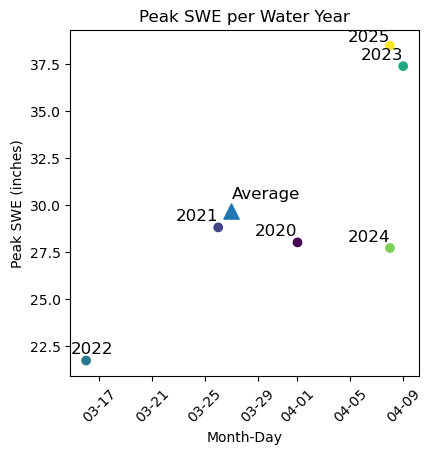

In [188]:

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(month_day_dt, SWE_selected["SWE"],  c=SWE_selected["wy"], marker='o')
plt.scatter(mean_date, mean_SWE, s=120,  marker='^')

# Format x-axis to show only month-day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.text(mean_date, mean_SWE  + 0.5, "Average", fontsize=12, ha='left', va='bottom')

# Add labels for each point (water year)
for i, row in SWE_selected.iterrows():
    texts = [plt.text(row['month_day_dt'], row['SWE'], row['wy'], fontsize=12, ha='right', va='bottom')]
    adjust_text(texts)

# Optional: rotate labels for readability
plt.xlabel("Month-Day")
plt.ylabel("Peak SWE (inches)")
plt.title("Peak SWE per Water Year")

plt.xticks(rotation=45)

plt.show()

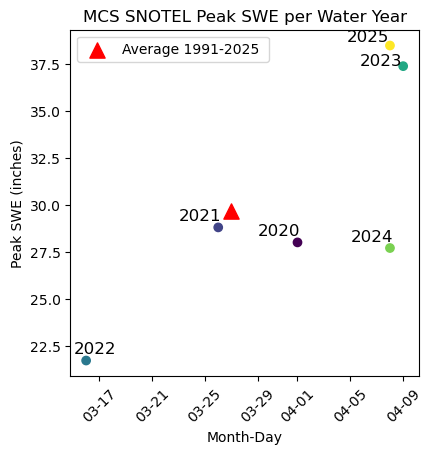

In [194]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(4.5, 4.5))

# Scatter all water year points (colored circles)
sc = ax.scatter(
    month_day_dt, SWE_selected["SWE"],
    c=SWE_selected["wy"], marker='o')

# Scatter the average point (black triangle) with legend entry
ax.scatter(
    mean_date, mean_SWE,
    color='red', s=120, marker='^',
    label="Average 1991-2025 "
)

# Label each water year (use one adjust_text call for all)
texts = []
for i, row in SWE_selected.iterrows():
    texts.append(ax.text(row['month_day_dt'], row['SWE'], row['wy'],
                         fontsize=12, ha='right', va='bottom'))
adjust_text(texts, ax=ax)

# Format x-axis to show only month-day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)

# Labels and title
ax.set_xlabel("Month-Day")
ax.set_ylabel("Peak SWE (inches)")
ax.set_title("MCS SNOTEL Peak SWE per Water Year")

# Add legend
ax.legend()

plt.show()
